## **Imports**

In [19]:
import os
import glob
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.calibration import CalibratedClassifierCV

## **Loading Data**

In [20]:
# Set your specific CSV path here
data_path = "/kaggle/input/datasets/bertvankeulen/cic-malmem-2022/MalMem2022.csv"

# Load the desired dataset directly
df = pd.read_csv(data_path)
print(f"Loaded dataset from: {data_path}")
print(f"Shape: {df.shape}")

Loaded dataset from: /kaggle/input/datasets/bertvankeulen/cic-malmem-2022/MalMem2022.csv
Shape: (58596, 58)


## **Preprocessing**

In [21]:
# Create a copy
df_processed = df.copy()

# Extract main Category for Multi-Class classification (Benign, Spyware, Ransomware, Trojan)
if 'Category' in df_processed.columns:
    df_processed['MultiClass_Target'] = df_processed['Category'].apply(
        lambda x: str(x).split('-')[0] if '-' in str(x) else str(x)
    )
elif 'Class' in df_processed.columns and df_processed['Class'].nunique() > 2:
    df_processed['MultiClass_Target'] = df_processed['Class'].apply(
        lambda x: str(x).split('-')[0] if '-' in str(x) else str(x)
    )
else:
    raise KeyError("Could not locate multi-class category column.")

print(df_processed.shape)

(58596, 59)


In [22]:
# Drop non-feature identification columns if present
drop_cols = ['Class', 'Category']
for col in drop_cols:
    if col in df_processed.columns:
        df_processed.drop(columns=[col], inplace=True)

print("Multi-class target distribution:")
print(df_processed['MultiClass_Target'].value_counts())

print(df_processed.shape)

Multi-class target distribution:
MultiClass_Target
Benign        29298
Spyware       10020
Ransomware     9791
Trojan         9487
Name: count, dtype: int64
(58596, 57)


In [23]:
# 1. Separate features (X) and target (y)
y = df_processed['MultiClass_Target']

# Drop target and any leftover non-numeric columns from features X
X = df_processed.drop(columns=['MultiClass_Target'])

# Ensure X only contains numeric columns (drops any leftover string columns if present)
X = X.select_dtypes(include=['number'])

# 2. Encode multi-class labels to numeric (0, 1, 2, 3)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Print Label Mapping and Shapes
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Encodings:", label_mapping)
print(X.shape)
print(y.shape)
print(y_encoded.shape)


Label Encodings: {'Benign': np.int64(0), 'Ransomware': np.int64(1), 'Spyware': np.int64(2), 'Trojan': np.int64(3)}
(58596, 55)
(58596,)
(58596,)


## **Splitting Data and Feature Scaling**

In [24]:
# Create a 70% Train, 15% Validation, and 15% Test Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Fit feature scaler on Train set only, then transform Val and Test
scaler_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

X_train_scaled = pd.DataFrame(scaler_pipeline.fit_transform(X_train), columns=X.columns)
X_val_scaled   = pd.DataFrame(scaler_pipeline.transform(X_val), columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler_pipeline.transform(X_test), columns=X.columns)

print("=== Split & Scaling Summary ===")
print(f"Train set shape:      {X_train_scaled.shape}, Labels: {y_train.shape}")
print(f"Validation set shape: {X_val_scaled.shape}, Labels: {y_val.shape}")
print(f"Test set shape:       {X_test_scaled.shape}, Labels: {y_test.shape}")

=== Split & Scaling Summary ===
Train set shape:      (41017, 55), Labels: (41017,)
Validation set shape: (8789, 55), Labels: (8789,)
Test set shape:       (8790, 55), Labels: (8790,)


In [25]:
# 5. Save Preprocessing Pipeline and Label Encoder
pipeline_path = "/kaggle/working/preprocessing_pipeline.joblib"
encoder_path = "/kaggle/working/label_encoder.joblib"

joblib.dump(scaler_pipeline, pipeline_path)
joblib.dump(label_encoder, encoder_path)

print(f"\nPreprocessing pipeline saved to: {pipeline_path}")
print(f"Label encoder saved to: {encoder_path}")


Preprocessing pipeline saved to: /kaggle/working/preprocessing_pipeline.joblib
Label encoder saved to: /kaggle/working/label_encoder.joblib


## **Model**

In [26]:
num_classes = len(np.unique(y_encoded))

# Initialize XGBoost Classifier for Multi-Class
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    n_estimators=150,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost Multi-Class Classifier...")
xgb_model.fit(
    X_train_scaled, 
    y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

# Save XGBoost Model
model_json_path = "/kaggle/working/xgboost_multiclass_model.json"
model_joblib_path = "/kaggle/working/xgboost_multiclass_model.joblib"

xgb_model.save_model(model_json_path)
joblib.dump(xgb_model, model_joblib_path)

print(f"Model saved to: {model_json_path}")
print(f"Model saved to: {model_joblib_path}")

Training XGBoost Multi-Class Classifier...
Model saved to: /kaggle/working/xgboost_multiclass_model.json
Model saved to: /kaggle/working/xgboost_multiclass_model.joblib


## **Evaluation**

=== Evaluation Results ===
Test Accuracy: 86.35%
Weighted F1-Score: 0.8633

Classification Report:
               precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      4395
  Ransomware       0.71      0.68      0.70      1469
     Spyware       0.77      0.78      0.77      1503
      Trojan       0.70      0.71      0.71      1423

    accuracy                           0.86      8790
   macro avg       0.79      0.79      0.79      8790
weighted avg       0.86      0.86      0.86      8790



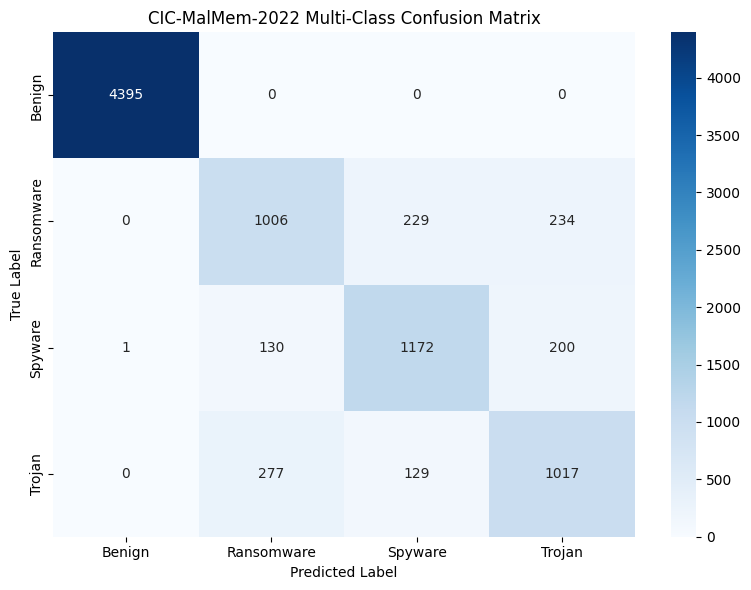


=== Saved Output Files in /kaggle/working/ ===
 - /kaggle/working/calibrated_xgboost_model.joblib
 - /kaggle/working/performance_metrics.json
 - /kaggle/working/xgboost_multiclass_model.json
 - /kaggle/working/.virtual_documents
 - /kaggle/working/preprocessing_pipeline.joblib
 - /kaggle/working/xgboost_multiclass_model.joblib
 - /kaggle/working/label_encoder.joblib


In [27]:
# Make predictions on test set
y_pred = xgb_model.predict(X_test_scaled)
target_names = [str(cls) for cls in label_encoder.classes_]

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
class_report_dict = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
class_report_str = classification_report(y_test, y_pred, target_names=target_names)

print("=== Evaluation Results ===")
print(f"Test Accuracy: {acc * 100:.2f}%")
print(f"Weighted F1-Score: {f1_weighted:.4f}\n")
print("Classification Report:\n", class_report_str)

# Generate Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('CIC-MalMem-2022 Multi-Class Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Save performance metrics to JSON file
metrics = {
    "accuracy": acc,
    "f1_score_weighted": f1_weighted,
    "classification_report": class_report_dict
}

metrics_json_path = "/kaggle/working/performance_metrics.json"
with open(metrics_json_path, 'w') as f:
    json.dump(metrics, f, indent=4)

print("\n=== Saved Output Files in /kaggle/working/ ===")
for file_name in os.listdir("/kaggle/working/"):
    print(f" - /kaggle/working/{file_name}")

## **Caliberation using Platt Scaling**

In [28]:
print("=== Performing Probability Calibration (Platt Scaling) ===")

# Using CalibratedClassifierCV with method='sigmoid' (Platt Scaling) and cv='prefit'
# since the base XGBoost model is already trained.
calibrated_xgb = CalibratedClassifierCV(estimator=xgb_model, method='sigmoid', cv='prefit')

# Fit calibration parameters on the Validation Set
calibrated_xgb.fit(X_val_scaled, y_val)

# Evaluate calibrated probabilities on Test Set
calibrated_probs = calibrated_xgb.predict_proba(X_test_scaled)
calibrated_preds = np.argmax(calibrated_probs, axis=1)

cal_acc = accuracy_score(y_test, calibrated_preds)
calibrated_f1_weighted = f1_score(y_test, calibrated_preds, average='weighted')
calibrated_f1_per_class = f1_score(y_test, calibrated_preds, average=None)

print(f"Calibrated Test Accuracy: {cal_acc * 100:.2f}%")
print(f"Calibrated Weighted F1-Score: {calibrated_f1_weighted:.4f}")
print(f"Calibrated Per class F1-Score: {calibrated_f1_per_class}")

# Save Calibrated Model Artifact
calibrated_model_path = "/kaggle/working/calibrated_xgboost_model.joblib"
joblib.dump(calibrated_xgb, calibrated_model_path)
print(f"Calibrated model saved to: {calibrated_model_path}")

=== Performing Probability Calibration (Platt Scaling) ===


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Calibrated Test Accuracy: 86.34%
Calibrated Weighted F1-Score: 0.8633
Calibrated Per class F1-Score: [0.99988625 0.69986169 0.77239549 0.70620881]
Calibrated model saved to: /kaggle/working/calibrated_xgboost_model.joblib


In [33]:
print("=== Platt Scaling Parameters (Sigmoid Weights & Biases) ===")

# Access the fitted classifier container
calibrated_classifier = calibrated_xgb.calibrated_classifiers_[0]

# Iterate through the binary calibrator for each class
for idx, class_name in enumerate(label_encoder.classes_):
    # Retrieve the sigmoid calibrator object for class 'idx'
    sigmoid_calibrator = calibrated_classifier.calibrators[idx]
    
    # Extract A (weight/scale) and B (bias/intercept)
    a_param = sigmoid_calibrator.a_
    b_param = sigmoid_calibrator.b_
    
    print(f"Class: {class_name:12s} | Weight (A): {a_param:10.5f} | Bias (B): {b_param:10.5f}")

=== Platt Scaling Parameters (Sigmoid Weights & Biases) ===
Class: Benign       | Weight (A):  -16.81018 | Bias (B):    8.06022
Class: Ransomware   | Weight (A):   -8.49008 | Bias (B):    4.00969
Class: Spyware      | Weight (A):   -8.39745 | Bias (B):    4.06662
Class: Trojan       | Weight (A):   -8.46588 | Bias (B):    4.01311


## **Inference**

In [29]:
def xgboost_calibrated_inference(input_data, calibrated_model_path, pipeline_path, encoder_path):
    """
    Performs standalone inference on new sample data using the Platt Scaled model.
    """
    # 1. Load artifacts
    calibrated_model = joblib.load(calibrated_model_path)
    scaler_pipe = joblib.load(pipeline_path)
    encoder = joblib.load(encoder_path)
    
    # 2. Format input data
    if isinstance(input_data, dict):
        df_input = pd.DataFrame([input_data])
    elif isinstance(input_data, pd.DataFrame):
        df_input = input_data.copy()
    else:
        raise ValueError("input_data must be a pandas DataFrame or dictionary.")
        
    # Ensure columns match training feature set
    if hasattr(scaler_pipe, "feature_names_in_"):
        expected_cols = scaler_pipe.feature_names_in_
        df_input = df_input[expected_cols]
    
    # 3. Preprocess / Scale
    scaled_data = scaler_pipe.transform(df_input)
    scaled_df = pd.DataFrame(scaled_data, columns=df_input.columns)
    
    # 4. Predict probabilities via Platt-scaled model
    probabilities = calibrated_model.predict_proba(scaled_df)
    predictions = np.argmax(probabilities, axis=1)
    
    # 5. Decode predicted labels
    class_names = encoder.inverse_transform(predictions)
    
    # Build results DataFrame
    results = pd.DataFrame({
        "Predicted_Class_ID": predictions,
        "Predicted_Class": class_names,
        "Calibrated_Confidence": np.max(probabilities, axis=1)
    })
    
    # Add per-class calibrated probability columns
    for idx, class_label in enumerate(encoder.classes_):
        results[f"Prob_{class_label}"] = probabilities[:, idx]
        
    return results

In [30]:
# --- SAMPLE INFERENCE RUN ---
# Select 4 representative samples from the unscaled Test set (one per unique class)
sample_indices = []
unique_targets = np.unique(y_test)

for target in unique_targets:
    match_idx = np.where(y_test == target)[0][0]
    sample_indices.append(match_idx)

# Extract raw feature inputs and ground truth labels
inference_samples = X_test.iloc[sample_indices].copy()
ground_truth_numeric = y_test[sample_indices]
ground_truth_labels = label_encoder.inverse_transform(ground_truth_numeric)

print("=== Running Custom Inference Pipeline (Calibrated Model) ===")
inference_results = xgboost_calibrated_inference(
    input_data=inference_samples,
    calibrated_model_path="/kaggle/working/calibrated_xgboost_model.joblib",
    pipeline_path="/kaggle/working/preprocessing_pipeline.joblib",
    encoder_path="/kaggle/working/label_encoder.joblib"
)

# Insert Ground Truth into results for side-by-side comparison
inference_results.insert(0, "Ground_Truth", ground_truth_labels)

# Display Complete Output
print("\nInference Results for 4 Test Samples:")
display(inference_results)

=== Running Custom Inference Pipeline (Calibrated Model) ===

Inference Results for 4 Test Samples:


,Ground_Truth,Predicted_Class_ID,Predicted_Class,Calibrated_Confidence,Prob_Benign,Prob_Ransomware,Prob_Spyware,Prob_Trojan
0,Benign,0,Benign,0.950179,0.950179,0.016932,0.016012,0.016876
1,Ransomware,3,Trojan,0.689033,0.000316,0.282790,0.027860,0.689033
2,Spyware,2,Spyware,0.821441,0.000303,0.159895,0.821441,0.018361
3,Trojan,3,Trojan,0.735877,0.000343,0.213827,0.049953,0.735877


In [31]:
print(inference_results.iloc[0])

Ground_Truth               Benign
Predicted_Class_ID              0
Predicted_Class            Benign
Calibrated_Confidence    0.950179
Prob_Benign              0.950179
Prob_Ransomware          0.016932
Prob_Spyware             0.016012
Prob_Trojan              0.016876
Name: 0, dtype: object
